Dataset Loaded Successfully
        Date  AQI  Humidity  Temperature    Fatigue  TomatoPrice  OnionPrice
0 2023-01-01  142        87           27   9.370311    22.230130   20.105462
1 2023-01-02  132        43           25   8.743861    22.437627   20.676026
2 2023-01-03   54        44           24   4.886566    20.856952   17.237344
3 2023-01-04  146        76           34  14.195069    23.219713   19.532993
4 2023-01-05  111        47           34   2.869935    26.068510   18.933834

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1000 non-null   datetime64[ns]
 1   AQI          1000 non-null   int64         
 2   Humidity     1000 non-null   int64         
 3   Temperature  1000 non-null   int64         
 4   Fatigue      1000 non-null   float64       
 5   TomatoPrice  1000 non-null   float64

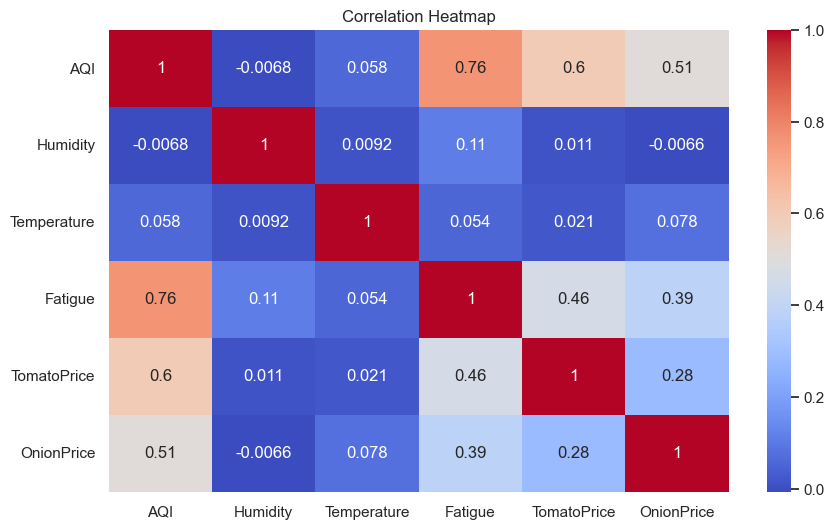

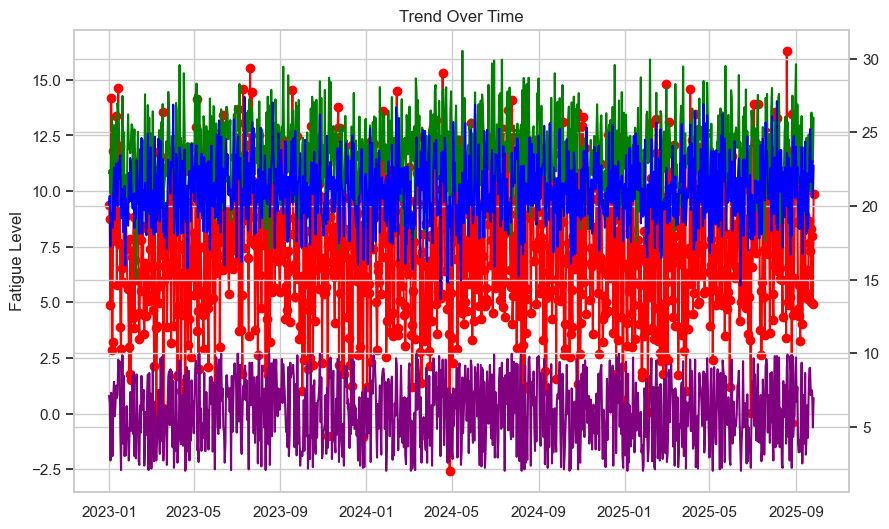

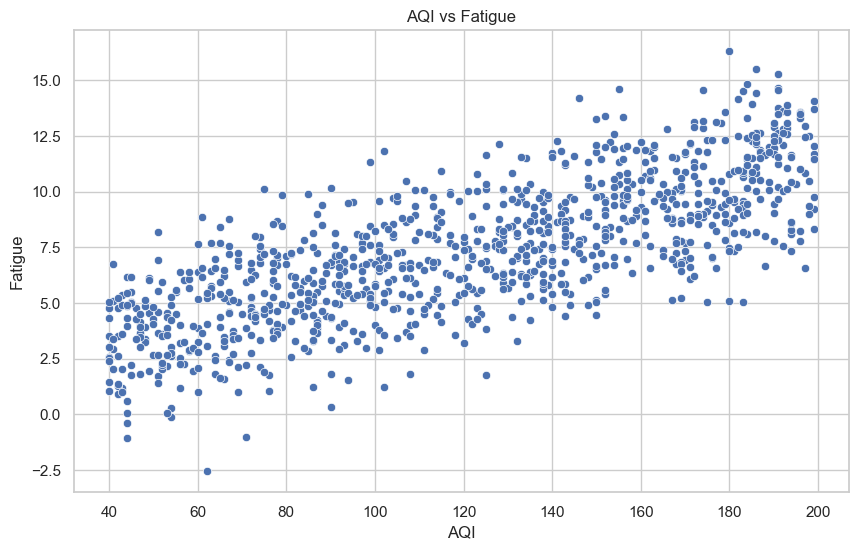

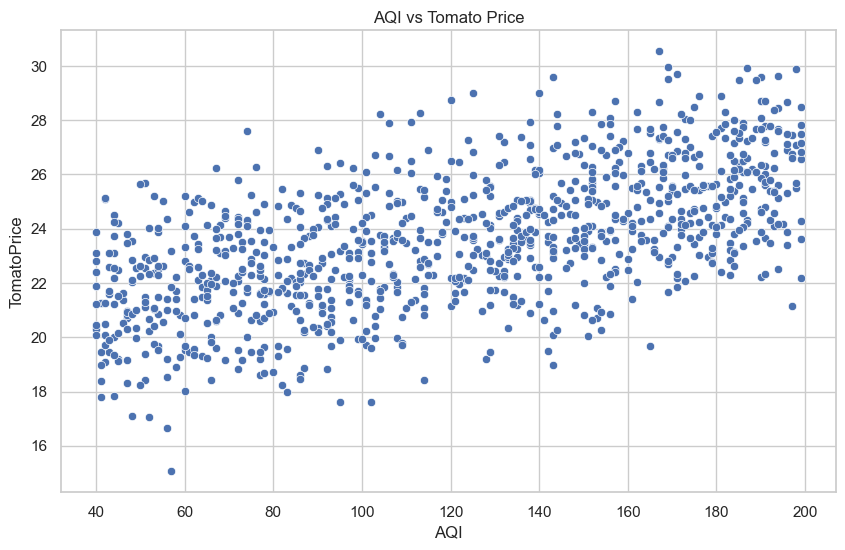

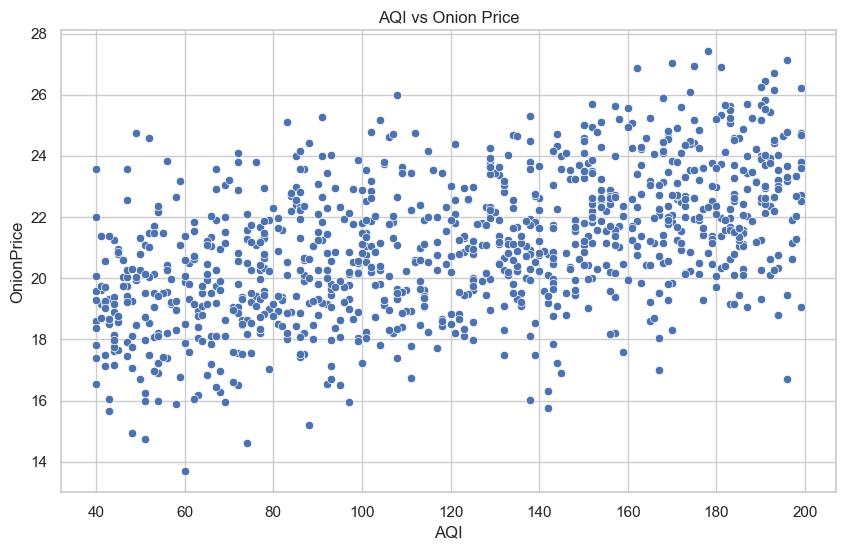


Models Trained Successfully


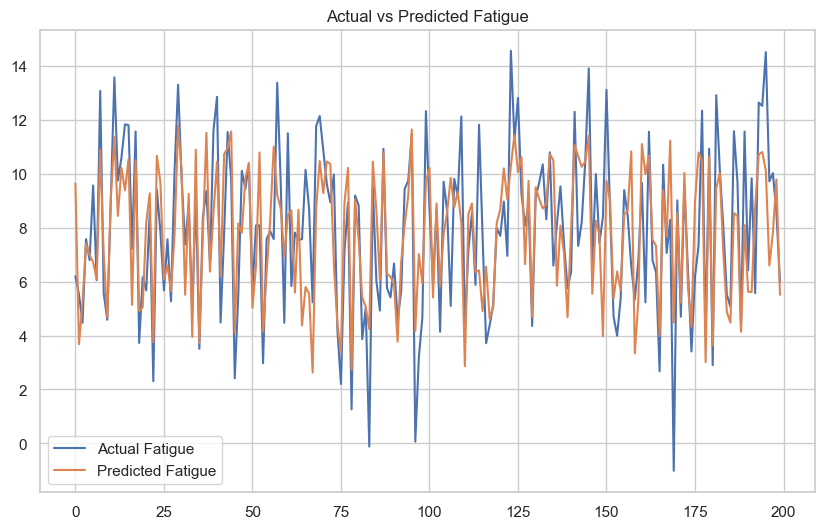

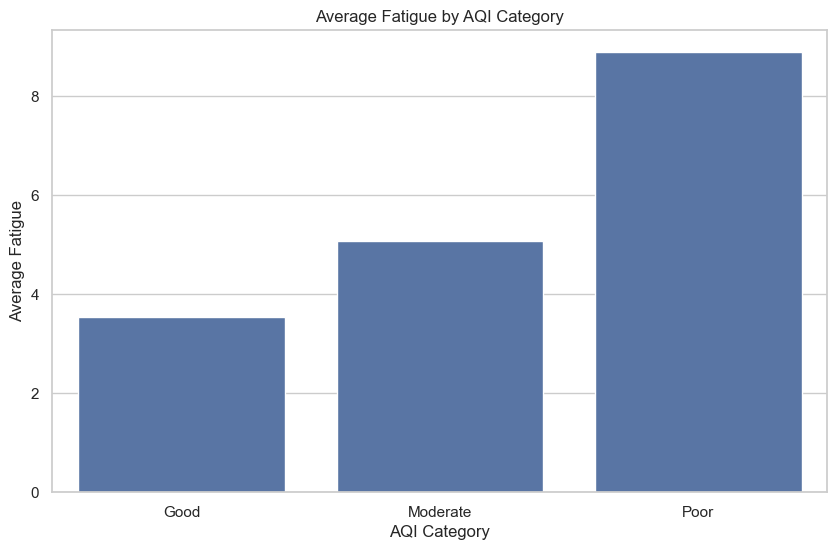

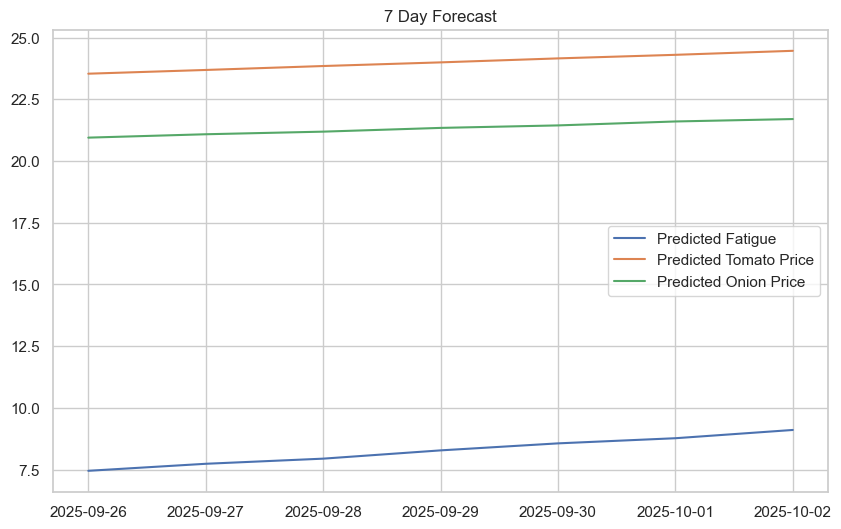


--- Prediction Tool ---

Predicted Results
Fatigue Level: 8.09
Tomato Price: 24.42
Onion Price: 21.83


In [12]:
# ==============================
# AIR QUALITY FATIGUE ANALYSIS
# ==============================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ==============================
# 2️⃣ LOAD DATA
# ==============================

data = pd.read_csv("final_data.csv")
data['Date'] = pd.to_datetime(data['Date'])

print("Dataset Loaded Successfully")
print(data.head())

# ==============================
# 3️⃣ DATA INFORMATION
# ==============================

print("\nDataset Information")
print(data.info())

print("\nStatistical Summary")
print(data.describe())

print("\nMissing Values")
print(data.isnull().sum())


# ==============================
# 4️⃣ GRAPH 1 : CORRELATION HEATMAP
# ==============================

numeric = data.select_dtypes(include=np.number)

plt.figure()
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# ==============================
# 5️⃣ GRAPH 2 : TREND OVER TIME
# ==============================

fig, ax1 = plt.subplots()

ax1.plot(data['Date'], data['Fatigue'], color='red', marker='o')
ax1.set_ylabel("Fatigue Level")

ax2 = ax1.twinx()

ax2.plot(data['Date'], data['TomatoPrice'], color='green')
ax2.plot(data['Date'], data['OnionPrice'], color='blue')
ax2.plot(data['Date'], data['AQI']/20, color='purple')

plt.title("Trend Over Time")
plt.show()


# ==============================
# 6️⃣ GRAPH 3 : AQI vs FATIGUE
# ==============================

plt.figure()
sns.scatterplot(x="AQI", y="Fatigue", data=data)
plt.title("AQI vs Fatigue")
plt.show()


# ==============================
# 7️⃣ GRAPH 4 : AQI vs TOMATO PRICE
# ==============================

plt.figure()
sns.scatterplot(x="AQI", y="TomatoPrice", data=data)
plt.title("AQI vs Tomato Price")
plt.show()


# ==============================
# 8️⃣ GRAPH 5 : AQI vs ONION PRICE
# ==============================

plt.figure()
sns.scatterplot(x="AQI", y="OnionPrice", data=data)
plt.title("AQI vs Onion Price")
plt.show()


# ==============================
# 9️⃣ MACHINE LEARNING MODEL
# ==============================

X = data[['AQI','Humidity','Temperature']]

y_fatigue = data['Fatigue']
y_tomato = data['TomatoPrice']
y_onion = data['OnionPrice']

X_train, X_test, y_train_f, y_test_f = train_test_split(X, y_fatigue, test_size=0.2, random_state=42)
_, _, y_train_t, y_test_t = train_test_split(X, y_tomato, test_size=0.2, random_state=42)
_, _, y_train_o, y_test_o = train_test_split(X, y_onion, test_size=0.2, random_state=42)

model_f = LinearRegression()
model_t = LinearRegression()
model_o = LinearRegression()

model_f.fit(X_train, y_train_f)
model_t.fit(X_train, y_train_t)
model_o.fit(X_train, y_train_o)

print("\nModels Trained Successfully")


# ==============================
# 🔟 PREDICTIONS
# ==============================

pred_f = model_f.predict(X_test)

# ==============================
# 1️⃣1️⃣ GRAPH 6 : ACTUAL vs PREDICTED
# ==============================

plt.figure()

plt.plot(y_test_f.values, label="Actual Fatigue")
plt.plot(pred_f, label="Predicted Fatigue")

plt.legend()
plt.title("Actual vs Predicted Fatigue")
plt.show()


# ==============================
# 1️⃣2️⃣ AQI CATEGORY
# ==============================

def aqi_category(aqi):

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    else:
        return "Very Poor"

data['AQI_Category'] = data['AQI'].apply(aqi_category)


# ==============================
# 1️⃣3️⃣ GRAPH 7 : AVG FATIGUE BY AQI
# ==============================

avg = data.groupby("AQI_Category")["Fatigue"].mean()

plt.figure()

sns.barplot(x=avg.index, y=avg.values)

plt.title("Average Fatigue by AQI Category")
plt.xlabel("AQI Category")
plt.ylabel("Average Fatigue")

plt.show()


# ==============================
# 1️⃣4️⃣ GRAPH 8 : 7 DAY FORECAST
# ==============================

future = pd.DataFrame({

"AQI":[120,125,130,135,140,145,150],
"Humidity":[72,73,71,74,75,73,76],
"Temperature":[29,30,29,31,30,32,31]

})

future_fatigue = model_f.predict(future)
future_tomato = model_t.predict(future)
future_onion = model_o.predict(future)

future_dates = pd.date_range(start=data['Date'].max(), periods=7)

plt.figure()

plt.plot(future_dates, future_fatigue, label="Predicted Fatigue")
plt.plot(future_dates, future_tomato, label="Predicted Tomato Price")
plt.plot(future_dates, future_onion, label="Predicted Onion Price")

plt.title("7 Day Forecast")
plt.legend()

plt.show()


# ==============================
# 1️⃣5️⃣ USER PREDICTION TOOL
# ==============================

print("\n--- Prediction Tool ---")

aqi = int(input("Enter AQI: "))
humidity = int(input("Enter Humidity: "))
temperature = int(input("Enter Temperature: "))

new_data = pd.DataFrame({
"AQI":[aqi],
"Humidity":[humidity],
"Temperature":[temperature]
})

fatigue_pred = model_f.predict(new_data)[0]
tomato_pred = model_t.predict(new_data)[0]
onion_pred = model_o.predict(new_data)[0]

print("\nPredicted Results")
print("Fatigue Level:", round(fatigue_pred,2))
print("Tomato Price:", round(tomato_pred,2))
print("Onion Price:", round(onion_pred,2))